In [1]:
### importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
## for geospatial/geocoding pip install geopy in terminal
import requests
from time import sleep
# for class weight
from sklearn.ensemble import RandomForestClassifier

In [2]:
# import and view dataset (Link:https://catalog.data.gov/dataset/vision-zero-crash-report-data)

df = pd.read_csv('C:\\Users\\aryap\\asds6302s26\\Austin_Crash_Report_Data_-_Crash_Level_Records.csv')
df.info()
df.describe()

C:\Users\aryap\AppData\Local\Temp\ipykernel_10348\3136777268.py:3: DtypeWarning: Columns (4,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\aryap\\asds6302s26\\Austin_Crash_Report_Data_-_Crash_Level_Records.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 47 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    228358 non-null  int64  
 1   Crash ID                              228355 non-null  float64
 2   crash_fatal_fl                        228358 non-null  bool   
 3   case_id                               225411 non-null  object 
 4   rpt_block_num                         197419 non-null  object 
 5   rpt_street_name                       228357 non-null  object 
 6   rpt_street_sfx                        155732 non-null  object 
 7   crash_speed_limit                     228358 non-null  int64  
 8   road_constr_zone_fl                   228356 non-null  object 
 9   latitude                              225329 non-null  float64
 10  longitude                             225329 non-null  float64
 11  

,ID,Crash ID,crash_speed_limit,latitude,longitude,crash_sev_id,sus_serious_injry_cnt,nonincap_injry_cnt,poss_injry_cnt,non_injry_cnt,...,motorcycle_serious_injury_count,other_death_count,other_serious_injury_count,micromobility_serious_injury_count,micromobility_death_count,Law enforcement fatality count,Reported street prefix,Estimated Maximum Comprehensive Cost,Estimated Total Comprehensive Cost,Location group
count,2.283580e+05,2.283550e+05,228358.000000,225329.000000,225329.000000,228358.000000,228358.000000,228358.000000,228358.000000,228358.000000,...,228358.000000,228358.0,228358.000000,228358.000000,228358.000000,228358.000000,0.0,2.283580e+05,2.283580e+05,208973.000000
mean,3.198317e+05,1.616475e+07,35.670509,30.299537,-97.738181,3.457308,0.034332,0.287378,0.352709,1.843719,...,0.004926,0.0,0.000044,0.000236,0.000039,0.003442,NaN,2.141706e+05,3.056280e+05,1.187201
std,3.826199e+05,2.788730e+06,22.544294,0.083108,0.052358,1.627714,0.211913,0.654602,0.753224,1.690187,...,0.072232,0.0,0.008370,0.016208,0.006278,0.062123,NaN,5.568484e+05,7.339058e+05,0.390074
min,2.000000e+00,1.115258e+07,-1.000000,30.098754,-97.927173,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,2.000000e+04,1.000000
25%,1.111752e+05,1.377692e+07,30.000000,30.233778,-97.769488,2.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,4.000000e+04,1.000000
50%,2.354695e+05,1.608885e+07,40.000000,30.285793,-97.736683,3.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+04,9.000000e+04,1.000000
75%,3.594558e+05,1.847572e+07,55.000000,30.364494,-97.702180,5.000000,0.000000,0.000000,0.000000,2.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,2.000000e+05,2.700000e+05,1.000000
max,1.803120e+06,2.134649e+07,85.000000,30.511625,-97.570148,5.000000,14.000000,57.000000,21.000000,75.000000,...,2.000000,0.0,3.000000,2.000000,1.000000,5.000000,NaN,3.500000e+06,4.224000e+07,2.000000


## Basic preprocessing and feature engineering (for MCC and Reg)

In [3]:
# basic preprocessing steps
# 1. standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.head()
# 2. check for missing values
df.isnull().sum()

id                                           0
crash_id                                     3
crash_fatal_fl                               0
case_id                                   2947
rpt_block_num                            30939
rpt_street_name                              1
rpt_street_sfx                           72626
crash_speed_limit                            0
road_constr_zone_fl                          2
latitude                                  3029
longitude                                 3029
crash_sev_id                                 0
sus_serious_injry_cnt                        0
nonincap_injry_cnt                           0
poss_injry_cnt                               0
non_injry_cnt                                0
unkn_injry_cnt                               0
tot_injry_cnt                                0
death_cnt                                    0
units_involved                               0
point                                     3029
motor_vehicle

crash id: MCAR; drop since only 3 missing
case_id: MNAR; add flag column then drop?
rpt_block_num: MAR; Add binary 'has_block_num' flag; drop raw col
rpt_street_name: 14k missing/high cardinality wo general pattern, will drop
rpt_street_sfx: Structural; Fill with 'NONE' (no suffix present)
road_constr_zone_fl: MCAR; Mode imputation (only 2 missing)
latitude: MAR/MNAR; KNN impute from address; add 'has_coords' flag
longitude: Same as latitude
point: drop, redundant
location_id: MAR/Struct; Add 'has_location_id' flag; drop raw col
location_group: MAR/Struct; Add 'has_location_group' flag or encode + flag
reported_street_prefix: Drop; 97% missing, no predictive value
address: MCAR; Mode imputation (only 7 missing)

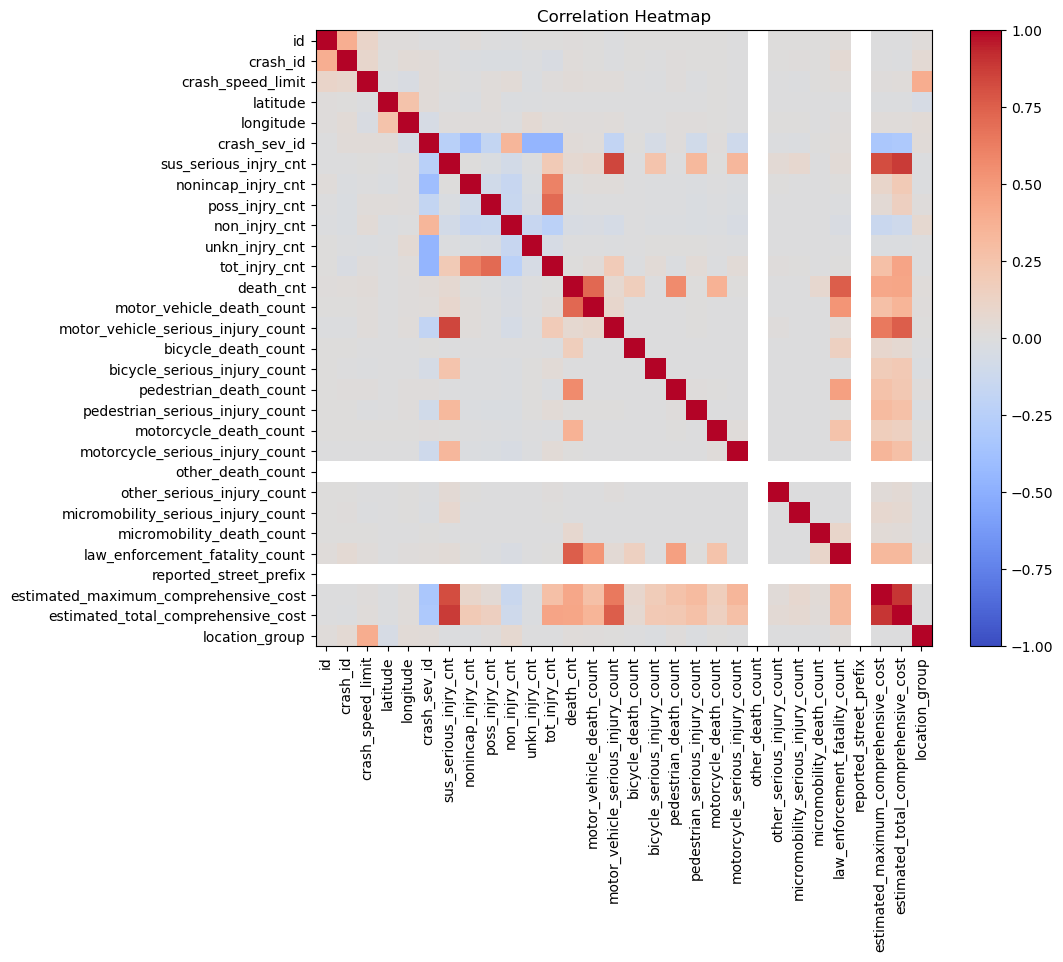

In [4]:
# creating correlation heatmap to identify highly correlated features
df_num = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = df_num.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

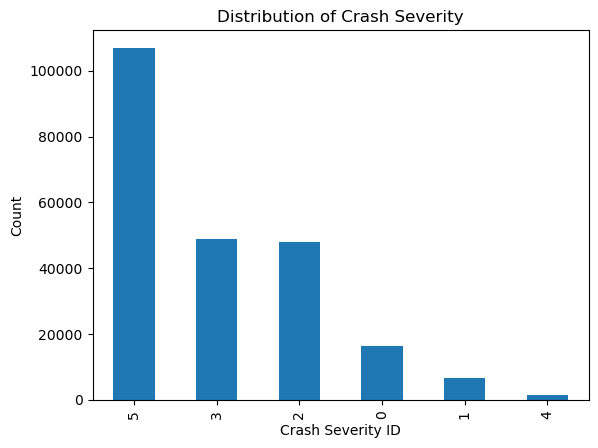

In [5]:
# 3. visulaize target class distribution and check for class imbalance
df['crash_sev_id'].value_counts()
df['crash_sev_id'].value_counts().plot(kind='bar')
plt.title('Distribution of Crash Severity')
plt.xlabel('Crash Severity ID')
plt.ylabel('Count')
plt.show()


0 = Unknown/Missing: Officer did not provide info or data was not recorded

1 = Fatal Injury(Inj) (K): injury resuled in death within 30 days of accident

2 = Suspected(Sus) serious Inj: incapacitating injury preventing continuation of daily activities (includes sever lacerations, unconsciousness, broken limbs, etc)

3 = Sus Minor Inj: Non-incapacitating injuries (bruises, abrasions, small cuts)

4 = Possible Inj: Injury is claimed/reported and indicated by behaviour (limping, moments of unconsciousness), but without visible wounds

5 = No Inj: No one involved in accident sustained an injury

*Based on Texas Peace Officer's Crash Report (CR-3) Code Sheet and Classification of Motor Vehicle Traffic Crashes in Texas manual. 

In [6]:
# 4. make copies of the original dataset for classification and regression tasks and begin cleaning
df_class = df.copy()
df_reg = df.copy()

In [7]:
# dropping high missing count
cols_drop = ['reported_street_prefix', 'rpt_street_sfx', 'rpt_block_num', 'rpt_street_name']

# columns not adding predictive value/redundant cols
cols_drop += ['id', 'crash_id', 'case_id', 'location_id', 'location_group', 'point', 'is_deleted', 'is_temporary_record']

# marking data leakage columns
cols_leak = ['death_cnt','tot_injry_cnt', 'sus_serious_injry_cnt', 'nonincap_injry_cnt', 'poss_injry_cnt', 'non_injry_cnt',
    'unkn_injry_cnt', 'motor_vehicle_death_count', 'motor_vehicle_serious_injury_count', 'bicycle_death_count', 
    'bicycle_serious_injury_count', 'pedestrian_death_count', 'pedestrian_serious_injury_count', 'motorcycle_death_count', 
    'motorcycle_serious_injury_count', 'other_death_count', 'other_serious_injury_count', 'micromobility_serious_injury_count',
    'micromobility_death_count', 'law_enforcement_fatality_count', 'estimated_total_comprehensive_cost', 'estimated_maximum_comprehensive_cost', 'crash_fatal_fl']

cols_drop += cols_leak

df_class.drop(columns=cols_drop, inplace=True)
df_reg.drop(columns=cols_drop, inplace=True)

df_class.isnull().sum()

crash_speed_limit                0
road_constr_zone_fl              2
latitude                      3029
longitude                     3029
crash_sev_id                     0
units_involved                   0
onsys_fl                         0
private_dr_fl                    0
crash_timestamp_us/central       0
crash_timestamp                  0
address                          7
collision_type                   0
dtype: int64

In [8]:
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_speed_limit           228358 non-null  int64  
 1   road_constr_zone_fl         228356 non-null  object 
 2   latitude                    225329 non-null  float64
 3   longitude                   225329 non-null  float64
 4   crash_sev_id                228358 non-null  int64  
 5   units_involved              228358 non-null  object 
 6   onsys_fl                    228358 non-null  bool   
 7   private_dr_fl               228358 non-null  bool   
 8   crash_timestamp_us/central  228358 non-null  object 
 9   crash_timestamp             228358 non-null  object 
 10  address                     228351 non-null  object 
 11  collision_type              228358 non-null  object 
dtypes: bool(2), float64(2), int64(2), object(6)
memory usage: 17.9+ MB


In [9]:
### address obj data type issue
# fixing unmarked missing values in crash_speed_limit column
df_class['crash_speed_limit'] = df_class['crash_speed_limit'].replace(-1, None)
df_class['crash_speed_limit'].isnull().sum()

np.int64(39481)

In [10]:
df_class['crash_speed_limit'].describe()

count     188877
unique        33
top           35
freq       35265
Name: crash_speed_limit, dtype: int64

In [11]:
# converting crash speed limit to numeric
df_class['crash_speed_limit'] = pd.to_numeric(df_class['crash_speed_limit'], errors='coerce')

# added missing flag just in case median imputation does not work well and we want to try treating missing as independent category and one hot encoding later
df_class['crash_speed_limit_missing'] = df_class['crash_speed_limit'].isnull().astype(int)

# decided median imputation is best for crash speed limit since it is a numeric column with outliers and skewed distribution (can also do treat missing as independent category and one hot encode but will try median imputation first)
df_class['crash_speed_limit'] = df_class['crash_speed_limit'].fillna(df_class['crash_speed_limit'].median())
df_class['crash_speed_limit'].isnull().sum()

np.int64(0)

In [12]:
df_class.isnull().sum()

crash_speed_limit                0
road_constr_zone_fl              2
latitude                      3029
longitude                     3029
crash_sev_id                     0
units_involved                   0
onsys_fl                         0
private_dr_fl                    0
crash_timestamp_us/central       0
crash_timestamp                  0
address                          7
collision_type                   0
crash_speed_limit_missing        0
dtype: int64

In [13]:
# converting flags to numeric
df_class['onsys_fl'] = df_class['onsys_fl'].astype(int)
df_class['private_dr_fl'] = df_class['private_dr_fl'].astype(int)
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_speed_limit           228358 non-null  float64
 1   road_constr_zone_fl         228356 non-null  object 
 2   latitude                    225329 non-null  float64
 3   longitude                   225329 non-null  float64
 4   crash_sev_id                228358 non-null  int64  
 5   units_involved              228358 non-null  object 
 6   onsys_fl                    228358 non-null  int64  
 7   private_dr_fl               228358 non-null  int64  
 8   crash_timestamp_us/central  228358 non-null  object 
 9   crash_timestamp             228358 non-null  object 
 10  address                     228351 non-null  object 
 11  collision_type              228358 non-null  object 
 12  crash_speed_limit_missing   228358 non-null  int64  
dtypes: float64(3),

In [14]:
# checking road construction zone flag column for missing values and unique values to determine how to handle
df_class[df_class['road_constr_zone_fl'].isna()]
df_class['road_constr_zone_fl'].unique()

array([False, True, nan], dtype=object)

In [15]:
df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].fillna(False)
df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].astype(bool)
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   crash_speed_limit           228358 non-null  float64
 1   road_constr_zone_fl         228358 non-null  bool   
 2   latitude                    225329 non-null  float64
 3   longitude                   225329 non-null  float64
 4   crash_sev_id                228358 non-null  int64  
 5   units_involved              228358 non-null  object 
 6   onsys_fl                    228358 non-null  int64  
 7   private_dr_fl               228358 non-null  int64  
 8   crash_timestamp_us/central  228358 non-null  object 
 9   crash_timestamp             228358 non-null  object 
 10  address                     228351 non-null  object 
 11  collision_type              228358 non-null  object 
 12  crash_speed_limit_missing   228358 non-null  int64  
dtypes: bool(1), fl

C:\Users\aryap\AppData\Local\Temp\ipykernel_10348\1921735656.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_class['road_constr_zone_fl'] = df_class['road_constr_zone_fl'].fillna(False)


In [16]:
df_class['units_involved'].value_counts()

units_involved
Passenger car                                                                   81407
Large passenger vehicle & Passenger car                                         76246
Large passenger vehicle                                                         34340
Motor vehicle – other & Passenger car                                            7499
Large passenger vehicle & Motor vehicle – other                                  3578
                                                                                ...  
Bicycle & Large passenger vehicle & Passenger car & Pedestrian                      1
Bicycle & Passenger car & Pedestrian                                                1
E-scooter & Motor vehicle – other & Passenger car                                   1
Micromobility device & Motor vehicle – other & Other/Unknown & Passenger car        1
Bicycle & Large passenger vehicle & Other/Unknown & Passenger car                   1
Name: count, Length: 80, dtype: int64

In [17]:
df_class['collision_type'].value_counts()

collision_type
ONE MOTOR VEHICLE - GOING STRAIGHT                             48738
SAME DIRECTION - ONE STRAIGHT-ONE STOPPED                      35407
SAME DIRECTION - BOTH GOING STRAIGHT-REAR END                  33913
ANGLE - BOTH GOING STRAIGHT                                    30441
OPPOSITE DIRECTION - ONE STRAIGHT-ONE LEFT TURN                21807
SAME DIRECTION - BOTH GOING STRAIGHT-SIDESWIPE                 16320
ANGLE - ONE STRAIGHT-ONE LEFT TURN                             10670
ANGLE - ONE STRAIGHT-ONE RIGHT TURN                             4757
ONE MOTOR VEHICLE - TURNING LEFT                                4720
SAME DIRECTION - ONE STRAIGHT-ONE LEFT TURN                     4382
ONE MOTOR VEHICLE - TURNING RIGHT                               3841
OPPOSITE DIRECTION - BOTH GOING STRAIGHT                        2925
SAME DIRECTION - ONE STRAIGHT-ONE RIGHT TURN                    2493
ONE MOTOR VEHICLE - OTHER                                       1129
ONE MOTOR VEHICLE -

High cardinality; apply grouping for collision types, extract number of units and presence of vehicle types for units involved?

In [18]:
def group_collision_types(ct):
    ct = str(ct)
    if 'REAR END' in ct:
        return 'rear_end'
    elif 'ANGLE' in ct:
        return 'angle'
    elif 'SIDESWIPE' in ct:
        return 'sideswipe'
    elif 'OPPOSITE DIRECTION' in ct:
        return 'head_on'
    elif 'ONE MOTOR VEHICLE' in ct:
        return 'single_vehicle'
    elif 'LEFT TURN' in ct or 'RIGHT TURN' in ct:
        return 'turning'
    elif 'BACKING' in ct or 'PARKED' in ct:
        return 'parking_related'
    else:
        return 'other'
df_class['collision_type_grouped'] = df_class['collision_type'].apply(group_collision_types)
df_class['collision_type_grouped'].value_counts()

collision_type_grouped
single_vehicle     59501
angle              47646
other              36383
rear_end           33913
head_on            26038
sideswipe          16320
turning             8544
parking_related       13
Name: count, dtype: int64

In [19]:
# one hot encoding collision type column and dropping original column since it is not ordinal in nature and there are only 8 categories, will try other encoding methods in future if needed
df_class = pd.get_dummies(df_class, columns=['collision_type_grouped'], drop_first=True)

In [20]:
df_class['num_units'] = df_class['units_involved'].apply(lambda x: len(str(x).split('&')))
#indicator flags for presence of different vehicle types in units involved column
df_class['has_pedestrian'] = df_class['units_involved'].str.contains('Pedestrian', case=False, na=False).astype(int)
df_class['has_motorcycle'] = df_class['units_involved'].str.contains('Motorcycle', case=False, na=False).astype(int)
df_class['has_bicycle'] = df_class['units_involved'].str.contains('Bicycle', case=False, na=False).astype(int)
df_class['has_micromobility'] = df_class['units_involved'].str.contains('Micromobility', case=False, na=False).astype(int)
df_class['has_large_vehicle'] = df_class['units_involved'].str.contains('Large passenger vehicle', case=False, na=False).astype(int)
df_class['has_other'] = df_class['units_involved'].str.contains('other', case=False, na=False).astype(int)

df_class = df_class.drop(columns=['units_involved', 'collision_type'])
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   crash_speed_limit                       228358 non-null  float64
 1   road_constr_zone_fl                     228358 non-null  bool   
 2   latitude                                225329 non-null  float64
 3   longitude                               225329 non-null  float64
 4   crash_sev_id                            228358 non-null  int64  
 5   onsys_fl                                228358 non-null  int64  
 6   private_dr_fl                           228358 non-null  int64  
 7   crash_timestamp_us/central              228358 non-null  object 
 8   crash_timestamp                         228358 non-null  object 
 9   address                                 228351 non-null  object 
 10  crash_speed_limit_missing               2283

In [21]:
df_class.head()

,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,crash_timestamp_us/central,crash_timestamp,address,...,collision_type_grouped_sideswipe,collision_type_grouped_single_vehicle,collision_type_grouped_turning,num_units,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other
0,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,01/15/2014 01:06:00 PM,4000 LOOP 1,...,False,False,False,1,0,0,0,0,0,0
1,30.0,False,NaN,NaN,5,0,0,01/10/2014 12:18:00 PM,01/10/2014 06:18:00 PM,E OLD EAST RIVERSIDE DR & PLEASANT VALLEY RD,...,False,True,False,1,0,0,0,0,0,0
2,45.0,False,NaN,NaN,5,1,0,01/12/2014 06:58:00 PM,01/13/2014 12:58:00 AM,4900 IH 35,...,False,False,False,2,0,0,0,0,1,0
3,65.0,False,NaN,NaN,5,1,0,01/22/2014 07:08:00 PM,01/23/2014 01:08:00 AM,STATE HIGHWAY 45 & FM 1826,...,False,True,False,1,0,1,0,0,0,0
4,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,01/15/2014 01:06:00 PM,4300 LOOP 1,...,False,False,False,2,0,0,0,0,1,0


In [22]:
# keep only one timestamp for date and time of crash (not using utc version)
df_class = df_class.drop(columns=['crash_timestamp'])
df_class['crash_timestamp'] = pd.to_datetime(df_class['crash_timestamp_us/central'], errors='coerce')
df_class['hour'] = df_class['crash_timestamp'].dt.hour
df_class['day_of_week'] = df_class['crash_timestamp'].dt.dayofweek
df_class


,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,crash_timestamp_us/central,address,crash_speed_limit_missing,...,num_units,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other,crash_timestamp,hour,day_of_week
0,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,4000 LOOP 1,0,...,1,0,0,0,0,0,0,2014-01-15 07:06:00,7,2
1,30.0,False,NaN,NaN,5,0,0,01/10/2014 12:18:00 PM,E OLD EAST RIVERSIDE DR & PLEASANT VALLEY RD,0,...,1,0,0,0,0,0,0,2014-01-10 12:18:00,12,4
2,45.0,False,NaN,NaN,5,1,0,01/12/2014 06:58:00 PM,4900 IH 35,1,...,2,0,0,0,0,1,0,2014-01-12 18:58:00,18,6
3,65.0,False,NaN,NaN,5,1,0,01/22/2014 07:08:00 PM,STATE HIGHWAY 45 & FM 1826,0,...,1,0,1,0,0,0,0,2014-01-22 19:08:00,19,2
4,65.0,False,NaN,NaN,5,1,0,01/15/2014 07:06:00 AM,4300 LOOP 1,0,...,2,0,0,0,0,1,0,2014-01-15 07:06:00,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228353,45.0,False,30.279487,-97.645713,2,0,0,12/19/2025 04:43:00 PM,5011 NIXON LN,0,...,2,0,0,0,0,1,0,2025-12-19 16:43:00,16,4
228354,40.0,False,30.254468,-97.762472,5,1,0,01/23/2026 03:35:00 PM,1300 S LAMAR BLVD,0,...,1,0,0,0,0,0,0,2026-01-23 15:35:00,15,4
228355,45.0,False,30.448384,-97.661850,2,0,0,02/15/2026 12:14:00 AM,15502 FM 1825,1,...,1,0,0,0,0,0,0,2026-02-15 00:14:00,0,6
228356,65.0,False,30.175795,-97.890291,5,1,0,03/03/2026 12:01:00 AM,S 11720 MOPAC EXPY SVRD SB EXPY,0,...,1,0,0,0,0,0,0,2026-03-03 00:01:00,0,1


In [23]:
# creating time buckets for rush hour vs non rush hours
def time_of_day(hour):
    if 7 <= hour < 10:
        return 'morning_rush'
    elif 10 <= hour < 16:
        return 'midday'
    elif 16 <= hour < 19:
        return 'evening_rush'
    else:
        return 'non_rush'
df_class['time_bucket'] = df_class['hour'].apply(time_of_day)

df_class = df_class.drop(columns=['crash_timestamp_us/central', 'crash_timestamp'])

In [24]:
print(df_class.shape, df.shape)

(228358, 26) (228358, 47)


## fixing lat and long missing columns (use the address from data and select random point on street segement for missing vals)

geocode w caching to avoid hitting API limits and for faster processing - store in dictionary and then map back to df
geolocator = Nominatim(user_agent="austin_crash_geocoder")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

address_to_latlong = {}
for address in unique_addy:
    try:
        location = geocode(f'{address}, AUSTIN, TX')
        if location:
            address_to_latlong[address] = (location.latitude, location.longitude)
        else:
            address_to_latlong[address] = (None, None)
    except Exception as e:
        print(f"Error geocoding address {address}: {e}")
        address_to_latlong[address] = (None, None)
mapping to dataframe
def coord_fill(row):
    if pd.isnull(row['latitude']) and row['address'] in address_to_latlong:
        lat, lon = address_to_latlong[row['address']]
        return pd.Series([lat, lon])
    return pd.Series([row['latitude'], row['longitude']])

df_class[['latitude', 'longitude']] = df_class.apply(coord_fill, axis=1)

In [25]:
## trial 2 for geocoding: using us census bureau geocoder API instead of nominatim since it is more reliable and has higher limits
# cleaning address for census bureau geocoder
def clean_address(address):
    if pd.isnull(address):
        return None
    address = address.strip().upper()
    # convert Intersection format to standard format for geocoding (e.g. "MAIN ST & 1ST AVE" to "MAIN ST AND 1ST AVE")
    address = address.replace('&', 'AND')
    # remove common abbreviations and punctuation
    replace_dict = {
        'STREET': 'ST',
        'AVENUE': 'AVE',
        'BOULEVARD': 'BLVD',
        'ROAD': 'RD',
        'DRIVE': 'DR',
        'LANE': 'LN'
    }
    for key, value in replace_dict.items():
        address = address.replace(key, value)
        
    if 'AUSTIN' not in address:
        address += ', AUSTIN, TX'
    return address


In [26]:
def geocode_census(address):
    url = 'https://geocoding.geo.census.gov/geocoder/locations/onelineaddress'
    params = {
        'address': address,
        'benchmark': 'Public_AR_Current',
        'format': 'json'
    }
    response = requests.get(url, params=params).json()

    try:
        coords = response['result']['addressMatches'][0]['coordinates']
        return coords['y'], coords['x']  # return lat, lon
    except (KeyError, IndexError):
        return None, None  # return None if geocoding fails

In [27]:
# adding alt link as well just in case
def geocode_opencage(address, api_key):
    url = 'https://api.opencagedata.com/geocode/v1/json'
    params = {
        'q': address,
        'key': api_key,
        'limit': 1
    }
    response = requests.get(url, params=params).json()
    if response['results']:
        lat = response['results'][0]['geometry']['lat']
        lon = response['results'][0]['geometry']['lng']
        return lat, lon
    else:
        return None, None

In [28]:
# define pipleine function to fill lat and long using census geocoder first and then opencage as backup
api_key = None

def geocode_pipeline(address):
    lat, lon = geocode_census(address)
    if lat is not None and lon is not None:
        return lat, lon
    lat, lon = geocode_opencage(address, api_key)
    if lat is not None and lon is not None:
        return lat, lon
    # fallback is none if both geocoders fail
    return None, None

In [29]:
# get unique addresses w missing lat and lon
df_class['address'] = df_class['address'].str.strip().str.upper()
df_class['cleaned_address'] = df_class['address'].apply(clean_address)
latlong_missing = df_class[df_class['latitude'].isnull() & df_class['cleaned_address'].notnull()]
# getting unique addresses with missing lat and long
unique_addy = latlong_missing['cleaned_address'].dropna().unique()
unique_addy.shape


(2391,)

In [30]:
# dictionary to store results
geocode_results = {}

for i, address in enumerate(unique_addy):
    lat, lon = geocode_pipeline(address)
    geocode_results[address] = (lat, lon)
    # avoiding rate limits
    sleep(0.2)

# converting geocode results to dataframe for merging
df_geo = pd.DataFrame.from_dict(geocode_results, orient='index', columns=['new_lat', 'new_lon']).reset_index().rename(columns={'index': 'cleaned_address'})
# merge geocoded results back to main df
df_class = df_class.merge(df_geo, on='cleaned_address', how='left')
# fill in lat and long from geocoding results where missing
df_class['latitude'] = df_class['latitude'].fillna(df_class['new_lat'])
df_class['longitude'] = df_class['longitude'].fillna(df_class['new_lon'])
# drop helper columns
df_class = df_class.drop(columns=['new_lat', 'new_lon'])
df_class.isnull().sum()

crash_speed_limit                            0
road_constr_zone_fl                          0
latitude                                  1389
longitude                                 1389
crash_sev_id                                 0
onsys_fl                                     0
private_dr_fl                                0
address                                      7
crash_speed_limit_missing                    0
collision_type_grouped_head_on               0
collision_type_grouped_other                 0
collision_type_grouped_parking_related       0
collision_type_grouped_rear_end              0
collision_type_grouped_sideswipe             0
collision_type_grouped_single_vehicle        0
collision_type_grouped_turning               0
num_units                                    0
has_pedestrian                               0
has_motorcycle                               0
has_bicycle                                  0
has_micromobility                            0
has_large_veh

In [31]:
df_class.head()

,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,onsys_fl,private_dr_fl,address,crash_speed_limit_missing,collision_type_grouped_head_on,...,has_pedestrian,has_motorcycle,has_bicycle,has_micromobility,has_large_vehicle,has_other,hour,day_of_week,time_bucket,cleaned_address
0,65.0,False,NaN,NaN,5,1,0,4000 LOOP 1,0,False,...,0,0,0,0,0,0,7,2,morning_rush,"4000 LOOP 1, AUSTIN, TX"
1,30.0,False,30.233668,-97.723509,5,0,0,E OLD EAST RIVERSIDE DR & PLEASANT VALLEY RD,0,False,...,0,0,0,0,0,0,12,4,midday,E OLD EAST RIVERSIDE DR AND PLEASANT VALLEY RD...
2,45.0,False,30.206351,-97.758268,5,1,0,4900 IH 35,1,False,...,0,0,0,0,1,0,18,6,evening_rush,"4900 IH 35, AUSTIN, TX"
3,65.0,False,NaN,NaN,5,1,0,STATE HIGHWAY 45 & FM 1826,0,False,...,0,1,0,0,0,0,19,2,non_rush,"STATE HIGHWAY 45 AND FM 1826, AUSTIN, TX"
4,65.0,False,NaN,NaN,5,1,0,4300 LOOP 1,0,False,...,0,0,0,0,1,0,7,2,morning_rush,"4300 LOOP 1, AUSTIN, TX"


In [32]:
df_rem_missing_latlon = df_class[df_class[['latitude', 'longitude']].isnull().any(axis=1)]

crash_sev_id
0    125
1     16
2    173
3    187
5    888
Name: count, dtype: int64


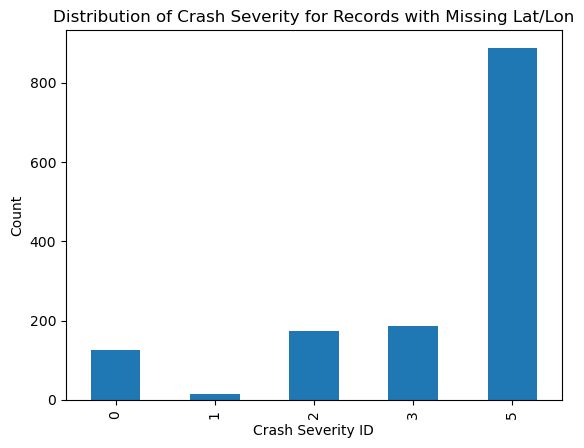

In [33]:
#checking sev_id distribution in remaining missing lat and long records to see if there is any pattern
sev_counts = df_rem_missing_latlon['crash_sev_id'].value_counts().sort_index()
print(sev_counts)

df_rem_missing_latlon['crash_sev_id'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Crash Severity for Records with Missing Lat/Lon')
plt.xlabel('Crash Severity ID')
plt.ylabel('Count')
plt.show()

In [34]:
# making second pass of geocoding for remaining missing lat and long values using the cleaned address
def geocode_google(address, api_key):
    url = 'https://maps.googleapis.com/maps/api/geocode/json'
    params = {
        'address': address,
        'key': api_key
    }
    response = requests.get(url, params=params).json()
    if response['results']:
        lat = response['results'][0]['geometry']['location']['lat']
        lon = response['results'][0]['geometry']['location']['lng']
        return lat, lon
    else:
        return None, None

In [35]:
def geocode_overpass_intersection(address):
    parts = address.split(' AND ')
    if len(parts) != 2:
        return None, None
    r1, r2 = parts[0], parts[1].split(',')[0]  # remove city/state 
    query = f"""
    [out:json];
    node
        ["highway"]
        (around 50, 30.2672, -97.7431)
        ["name"="{r1}|{r2}"];
    out;
    """
    url = 'http://overpass-api.de/api/interpreter'
    response = requests.post(url, params={'data': query}).json()

    if response['elements']:
        lat = response['elements'][0]['lat']
        lon = response['elements'][0]['lon']
        return lat, lon
    return None, None

In [36]:
api_key = None

def geocode_pipeline_v2(address):
    # try google
    lat, lon = geocode_google(address, api_key)
    if lat is not None and lon is not None:
        return lat, lon
    
    # try overpass
    if ' AND ' in address:
        lat, lon = geocode_overpass_intersection(address)
        if lat is not None and lon is not None:
            return lat, lon


    return None, None

In [37]:
geocode_results2 = {}

for i, address in enumerate(unique_addy):
    lat, lon = geocode_pipeline_v2(address)
    geocode_results2[address] = (lat, lon)
    # avoiding rate limits
    sleep(0.2)

# converting geocode results to dataframe for merging
df_geo2 = pd.DataFrame.from_dict(geocode_results2, orient='index', columns=['new_lat', 'new_lon']).reset_index().rename(columns={'index': 'cleaned_address'})
# merge geocoded results back to main df
df_class = df_class.merge(df_geo2, on='cleaned_address', how='left')
# fill in lat and long from geocoding results where missing
df_class['latitude'] = df_class['latitude'].fillna(df_class['new_lat'])
df_class['longitude'] = df_class['longitude'].fillna(df_class['new_lon'])
# drop helper columns
df_class = df_class.drop(columns=['new_lat', 'new_lon'])
df_class.isnull().sum()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

decided to drop missing since theres only 7 addresses with missing lat and long after two passes of geocoding and there does not seem to be any pattern in crash severity distribution for the missing lat and long records that would bias the model if dropped. Additionally, the number of records with missing lat and long is very small compared to the overall dataset so dropping them should not have a significant impact on model performance.

## regression dataset
vif for reg task?

In [ ]:
# recreating df_reg
df_reg = df_class.copy()

# bringing back necessary columns from raw data
inj_cols = ['sus_serious_injry_cnt', 'nonincap_injry_cnt', 'poss_injry_cnt']

df_reg[inj_cols] = df[inj_cols]
df_reg.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          228358 non-null  float64
 1   road_constr_zone_fl        228358 non-null  bool   
 2   latitude                   226969 non-null  float64
 3   longitude                  226969 non-null  float64
 4   crash_sev_id               228358 non-null  int64  
 5   onsys_fl                   228358 non-null  int64  
 6   private_dr_fl              228358 non-null  int64  
 7   address                    228351 non-null  object 
 8   crash_speed_limit_missing  228358 non-null  int64  
 9   collision_type_grouped     228358 non-null  object 
 10  num_units                  228358 non-null  int64  
 11  has_pedestrian             228358 non-null  int64  
 12  has_motorcycle             228358 non-null  int64  
 13  has_bicycle                22

In [ ]:
# creating target variable for regression task by summing up different injury counts to get total injury count
df_reg['injury_count'] = df_reg['sus_serious_injry_cnt'] + df_reg['nonincap_injry_cnt'] + df_reg['poss_injry_cnt']

In [ ]:
# sanity check of added columns
df_reg['injury_count'].describe()

count    228358.000000
mean          0.674419
std           0.972451
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          61.000000
Name: injury_count, dtype: float64

In [ ]:
df_reg['injury_count'].value_counts()

injury_count
0     124411
1      71719
2      21513
3       6715
4       2353
5        925
6        397
7        173
8         74
9         31
10        17
12        10
11         7
15         3
13         3
14         2
21         1
18         1
22         1
61         1
17         1
Name: count, dtype: int64

In [ ]:
# removing individual injury count columns and other columns not needed for regression task
df_reg = df_reg.drop(columns=['sus_serious_injry_cnt', 'nonincap_injry_cnt', 'poss_injry_cnt', 'address', 'crash_sev_id'])
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228358 entries, 0 to 228357
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          228358 non-null  float64
 1   road_constr_zone_fl        228358 non-null  bool   
 2   latitude                   226969 non-null  float64
 3   longitude                  226969 non-null  float64
 4   onsys_fl                   228358 non-null  int64  
 5   private_dr_fl              228358 non-null  int64  
 6   crash_speed_limit_missing  228358 non-null  int64  
 7   collision_type_grouped     228358 non-null  object 
 8   num_units                  228358 non-null  int64  
 9   has_pedestrian             228358 non-null  int64  
 10  has_motorcycle             228358 non-null  int64  
 11  has_bicycle                228358 non-null  int64  
 12  has_micromobility          228358 non-null  int64  
 13  has_large_vehicle          22

In [ ]:
df_reg = df_reg.dropna(subset=['latitude', 'longitude'])
df_reg = df_reg.drop(columns=['cleaned_address'])
df_reg.isnull().sum()

crash_speed_limit            0
road_constr_zone_fl          0
latitude                     0
longitude                    0
onsys_fl                     0
private_dr_fl                0
crash_speed_limit_missing    0
collision_type_grouped       0
num_units                    0
has_pedestrian               0
has_motorcycle               0
has_bicycle                  0
has_micromobility            0
has_large_vehicle            0
has_other                    0
hour                         0
day_of_week                  0
time_bucket                  0
injury_count                 0
dtype: int64

## back to fixing df_class

In [ ]:
# combine rare classes in crash severity id  OR use class weightsto address class imbalance
# smote dataset for after base models in MCC and Reg

In [ ]:
# drop missing lat/lon and unknown crash severity record.
df_class = df_class.dropna(subset=['latitude', 'longitude'])
df_class = df_class[df_class['crash_sev_id'] != 0]

In [ ]:
df_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210587 entries, 1 to 228357
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          210587 non-null  float64
 1   road_constr_zone_fl        210587 non-null  bool   
 2   latitude                   210587 non-null  float64
 3   longitude                  210587 non-null  float64
 4   crash_sev_id               210587 non-null  int64  
 5   onsys_fl                   210587 non-null  int64  
 6   private_dr_fl              210587 non-null  int64  
 7   address                    210580 non-null  object 
 8   crash_speed_limit_missing  210587 non-null  int64  
 9   collision_type_grouped     210587 non-null  object 
 10  num_units                  210587 non-null  int64  
 11  has_pedestrian             210587 non-null  int64  
 12  has_motorcycle             210587 non-null  int64  
 13  has_bicycle                210587 

In [ ]:
## Making 3 different datasets for classification task: one with combined classes in crash severity, one with class weights for imbalanced classes, and one for ordinal regression. Will try all approaches and see which works better.

# weighted dataset
df_class_weighted = df_class.copy()

In [ ]:
# defining severity grouping function for combined class dataset
def severity_grouping(x):
    if x == 1:  # Fatal
        return 'Fatal'
    elif x == 2:  # serious
        return 'Serious'
    elif x == 3:  # non-incapacitating injury
        return 'Minor'
    elif x == 4:  # merge into minor class
        return 'Minor'
    else:
        return 'None'

# grouped severity class dataset
df_class_grouped = df_class.copy()
df_class_grouped['crash_sev_grouped'] = df_class_grouped['crash_sev_id'].apply(severity_grouping)

In [ ]:
print(df_class_grouped['crash_sev_grouped'].value_counts(normalize=True))
print(df_class['crash_sev_id'].value_counts(normalize=True))

crash_sev_grouped
None       0.503934
Minor      0.237375
Serious    0.226818
Fatal      0.031873
Name: proportion, dtype: float64
crash_sev_id
5    0.503934
3    0.231083
2    0.226818
1    0.031873
4    0.006292
Name: proportion, dtype: float64


In [ ]:
df_class_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210587 entries, 1 to 228357
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          210587 non-null  float64
 1   road_constr_zone_fl        210587 non-null  bool   
 2   latitude                   210587 non-null  float64
 3   longitude                  210587 non-null  float64
 4   crash_sev_id               210587 non-null  int64  
 5   onsys_fl                   210587 non-null  int64  
 6   private_dr_fl              210587 non-null  int64  
 7   address                    210580 non-null  object 
 8   crash_speed_limit_missing  210587 non-null  int64  
 9   collision_type_grouped     210587 non-null  object 
 10  num_units                  210587 non-null  int64  
 11  has_pedestrian             210587 non-null  int64  
 12  has_motorcycle             210587 non-null  int64  
 13  has_bicycle                210587 

In [ ]:
df_class_grouped = df_class_grouped.drop(columns=['crash_sev_id', 'cleaned_address', 'address', 'hour'])

In [ ]:
# ordinal dataset
df_class_ordinal = df_class.copy()

severity_map = {
    5: 0,  # None
    4: 1,  # possible injury
    3: 2,  # minor
    2: 3,  # serious
    1: 4   # fatal
}

df_class_ordinal['crash_sev_ordinal'] = df_class_ordinal['crash_sev_id'].map(severity_map)
df_class_ordinal = df_class_ordinal.drop(columns=['crash_sev_id', 'cleaned_address', 'address', 'hour'])
df_class_ordinal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210587 entries, 1 to 228357
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crash_speed_limit          210587 non-null  float64
 1   road_constr_zone_fl        210587 non-null  bool   
 2   latitude                   210587 non-null  float64
 3   longitude                  210587 non-null  float64
 4   onsys_fl                   210587 non-null  int64  
 5   private_dr_fl              210587 non-null  int64  
 6   crash_speed_limit_missing  210587 non-null  int64  
 7   collision_type_grouped     210587 non-null  object 
 8   num_units                  210587 non-null  int64  
 9   has_pedestrian             210587 non-null  int64  
 10  has_motorcycle             210587 non-null  int64  
 11  has_bicycle                210587 non-null  int64  
 12  has_micromobility          210587 non-null  int64  
 13  has_large_vehicle          210587 

## SAVING DATASETS

In [ ]:
df_class.to_csv('df_class_cleaned.csv', index=False)
df_reg.to_csv('df_reg_cleaned.csv', index=False)
df_class_ordinal.to_csv('df_class_ordinal.csv', index=False)
df_class_grouped.to_csv('df_class_grouped.csv', index=False)


## EDA of df_class for MCC

In [ ]:
### Target Distribution
df_class['crash_sev_id'].value_counts().sort_index()
df_class['crash_sev_id'].value_counts(normalize=True) * 100

crash_sev_id
5    50.393424
3    23.108264
2    22.681837
1     3.187281
4     0.629194
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Crash Speed Limit by Crash Severity')

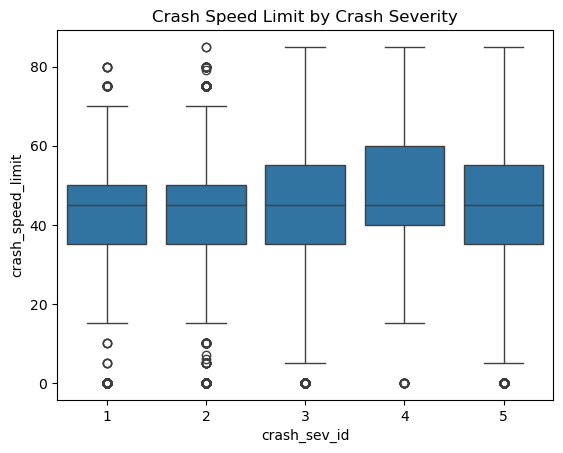

In [ ]:
### Features v target relationships
## numerical vs severity
sns.boxplot(x='crash_sev_id', y='crash_speed_limit', data=df_class)
plt.title('Crash Speed Limit by Crash Severity')

# need to do for num units and hour?

Text(0.5, 1.0, 'Collision Type by Crash Severity')

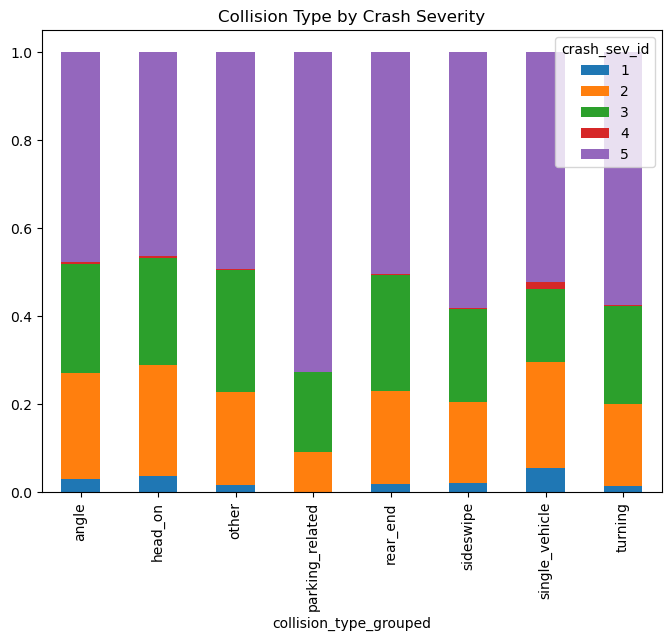

In [ ]:
## categorical v target
ct = pd.crosstab(df_class['collision_type_grouped'], df_class['crash_sev_id'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title('Collision Type by Crash Severity')

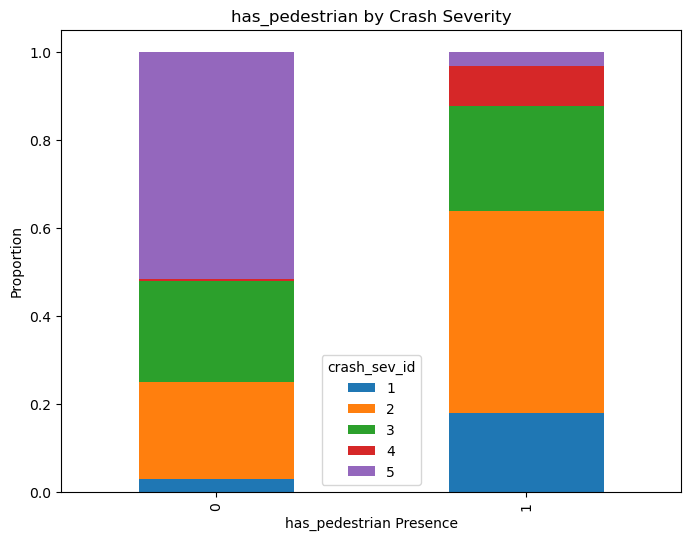

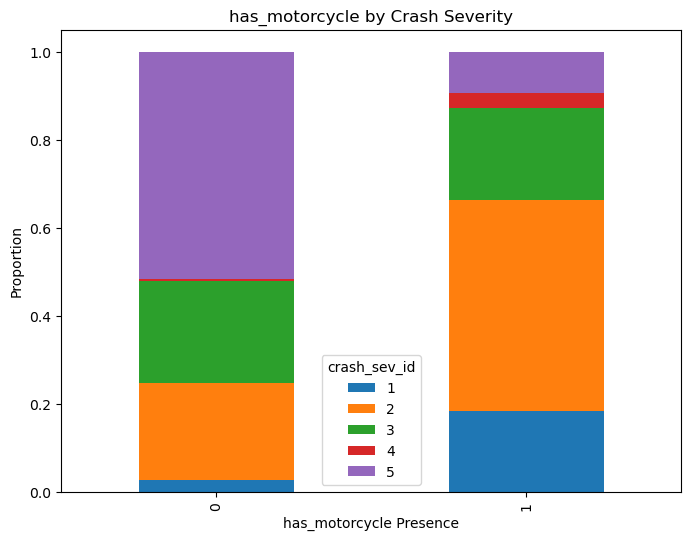

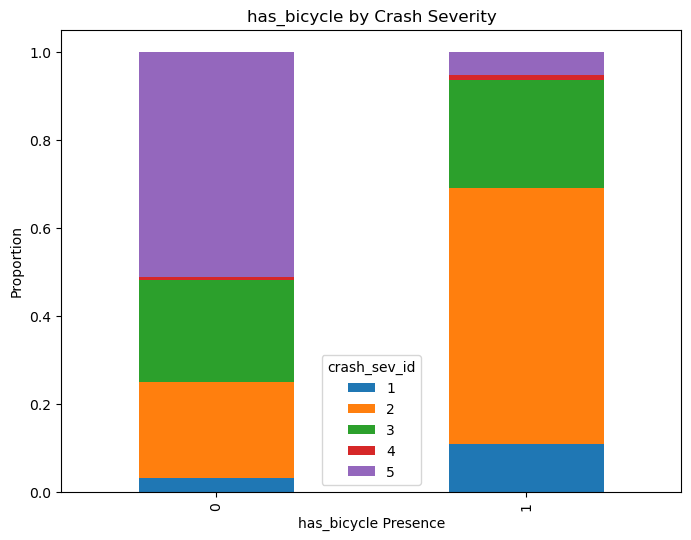

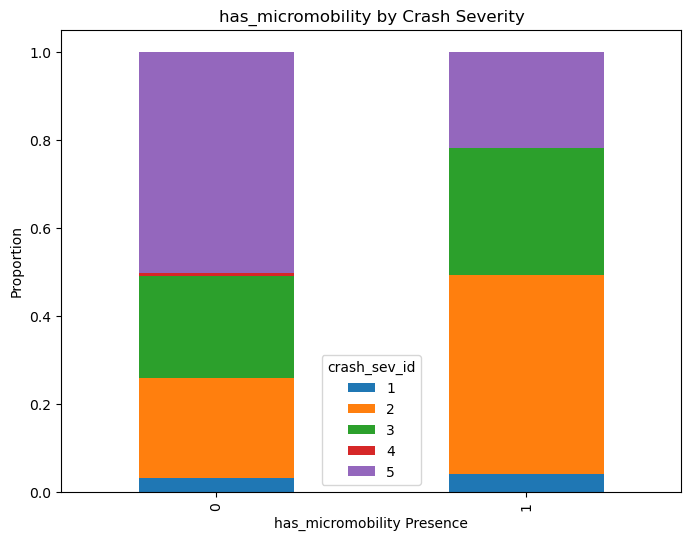

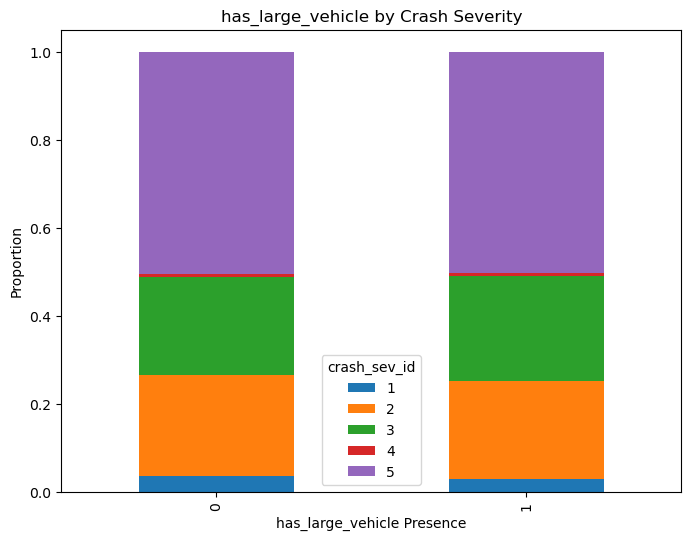

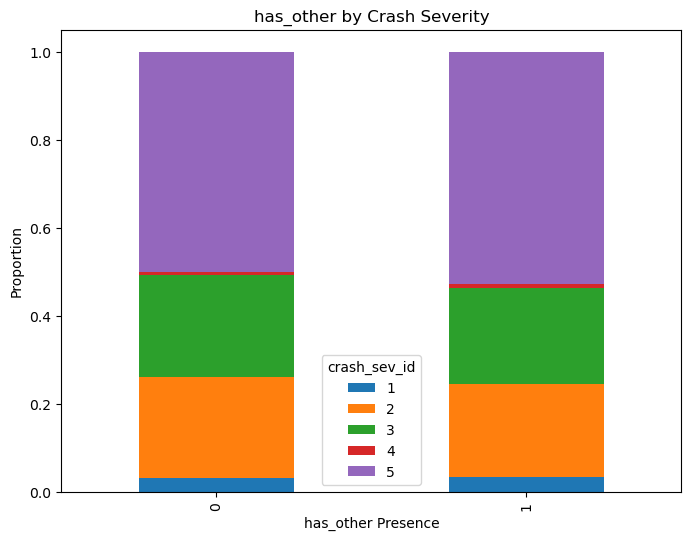

In [ ]:
## binary features v target
feat = ['has_pedestrian', 'has_motorcycle', 'has_bicycle', 'has_micromobility', 'has_large_vehicle', 'has_other']
for f in feat:
    ct = pd.crosstab(df_class[f], df_class['crash_sev_id'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(8,6))
    plt.title(f'{f} by Crash Severity')
    plt.xlabel(f'{f} Presence')
    plt.ylabel('Proportion')
    plt.show()

In [ ]:
### time based
## severity by hour
sns.lineplot(x='hour', y='crash_sev_id', data=df_class)
plt.title('Crash Severity by Hour')


In [ ]:
## time bucket v severity
pd.crosstab(df_class['time_bucket'], df_class['crash_sev_id'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,6))

In [ ]:
## day of week v severity
pd.crosstab(df_class['day_of_week'], df_class['crash_sev_id'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,6))

In [ ]:
pd.crosstab(df_class['day_of_week'], df_class['crash_sev_id'], normalize='index')

In [ ]:
### Geospatial features v severity
## scatterplot
plt.scatter(df_class['longitude'], df_class['latitude'], c=df_class['crash_sev_id'], cmap='viridis', alpha=0.3)
plt.title('Crash Severity by Location')

In [ ]:
# 4. make copy and drop rows with class 0
df_class = df.copy()
df_reg = df.copy()
df_class = df_class[df_class['crash_sev_id'] != 0]